In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [5]:
DATA_PATH = Path("D:/pr 1 internship/data/raw")

print(DATA_PATH)

D:\pr 1 internship\data\raw


In [6]:
ratings = pd.read_csv(
    DATA_PATH / "u.data",
    sep="\t",
    names=["userId", "movieId", "rating", "timestamp"]
)

ratings.head()

,userId,movieId,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [7]:
print("Shape:", ratings.shape)
print("\nColumns:")
print(ratings.columns.tolist())

Shape: (100000, 4)

Columns:
['userId', 'movieId', 'rating', 'timestamp']


In [8]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   userId     100000 non-null  int64
 1   movieId    100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [9]:
ratings.describe()

,userId,movieId,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


In [10]:
movies = pd.read_csv(
    DATA_PATH / "u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0, 1, 2],
    names=["movieId", "title", "release_date"]
)

movies.head()

,movieId,title,release_date
0,1,Toy Story (1995),01-Jan-1995
1,2,GoldenEye (1995),01-Jan-1995
2,3,Four Rooms (1995),01-Jan-1995
3,4,Get Shorty (1995),01-Jan-1995
4,5,Copycat (1995),01-Jan-1995


In [11]:
print("Shape:", movies.shape)
movies.info()

Shape: (1682, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   movieId       1682 non-null   int64 
 1   title         1682 non-null   object
 2   release_date  1681 non-null   object
dtypes: int64(1), object(2)
memory usage: 39.6+ KB


In [12]:
print("Missing values in ratings:")
print(ratings.isnull().sum())

print("\nMissing values in movies:")
print(movies.isnull().sum())

Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Missing values in movies:
movieId         0
title           0
release_date    1
dtype: int64


In [13]:
print("Duplicate ratings:", ratings.duplicated().sum())
print("Duplicate movies:", movies.duplicated().sum())

Duplicate ratings: 0
Duplicate movies: 0


In [14]:
movies["release_date"] = movies["release_date"].fillna("Unknown")


In [15]:
movies.isnull().sum()

movieId         0
title           0
release_date    0
dtype: int64

In [16]:
OUTPUT_PATH = Path("D:\pr 1 internship/data")

ratings.to_csv(
    OUTPUT_PATH / "ratings.csv",
    index=False
)

movies.to_csv(
    OUTPUT_PATH / "movies.csv",
    index=False
)

print("CSV files created successfully!")

CSV files created successfully!


<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\PC\AppData\Local\Temp\ipykernel_20636\1673819304.py:1: SyntaxWarning: invalid escape sequence '\p'
  OUTPUT_PATH = Path("D:\pr 1 internship/data")


In [17]:
print("Number of Users:", ratings["userId"].nunique())
print("Number of Movies:", ratings["movieId"].nunique())
print("Number of Ratings:", len(ratings))

Number of Users: 943
Number of Movies: 1682
Number of Ratings: 100000


In [18]:
print("Rating range:", ratings["rating"].min(), "to", ratings["rating"].max())

Rating range: 1 to 5


In [19]:
print("Average rating:", ratings["rating"].mean())

Average rating: 3.52986


In [20]:
rating_counts = ratings["rating"].value_counts().sort_index()

print(rating_counts)

rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64


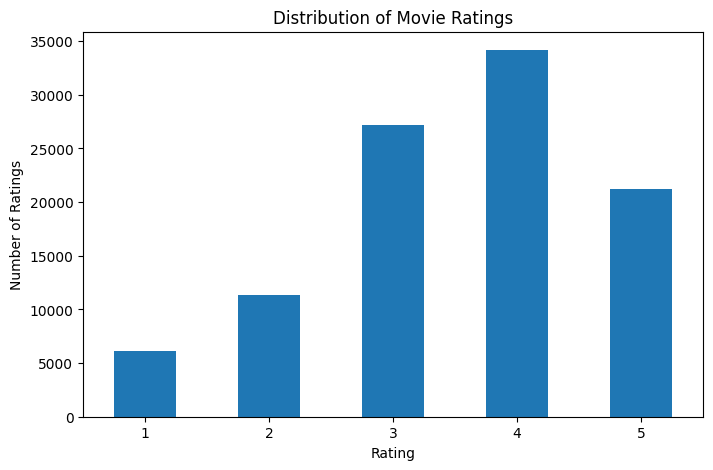

In [21]:
plt.figure(figsize=(8, 5))

rating_counts.plot(kind="bar")

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=0)

plt.show()

In [22]:
movie_rating_counts = (
    ratings.groupby("movieId")
    .size()
    .reset_index(name="rating_count")
)

movie_rating_counts.head()

,movieId,rating_count
0,1,452
1,2,131
2,3,90
3,4,209
4,5,86


In [23]:
most_rated_movies = (
    movie_rating_counts
    .merge(movies[["movieId", "title"]], on="movieId")
    .sort_values("rating_count", ascending=False)
)

most_rated_movies.head(10)

,movieId,rating_count,title
49,50,583,Star Wars (1977)
257,258,509,Contact (1997)
99,100,508,Fargo (1996)
180,181,507,Return of the Jedi (1983)
293,294,485,Liar Liar (1997)
285,286,481,"English Patient, The (1996)"
287,288,478,Scream (1996)
0,1,452,Toy Story (1995)
299,300,431,Air Force One (1997)
120,121,429,Independence Day (ID4) (1996)


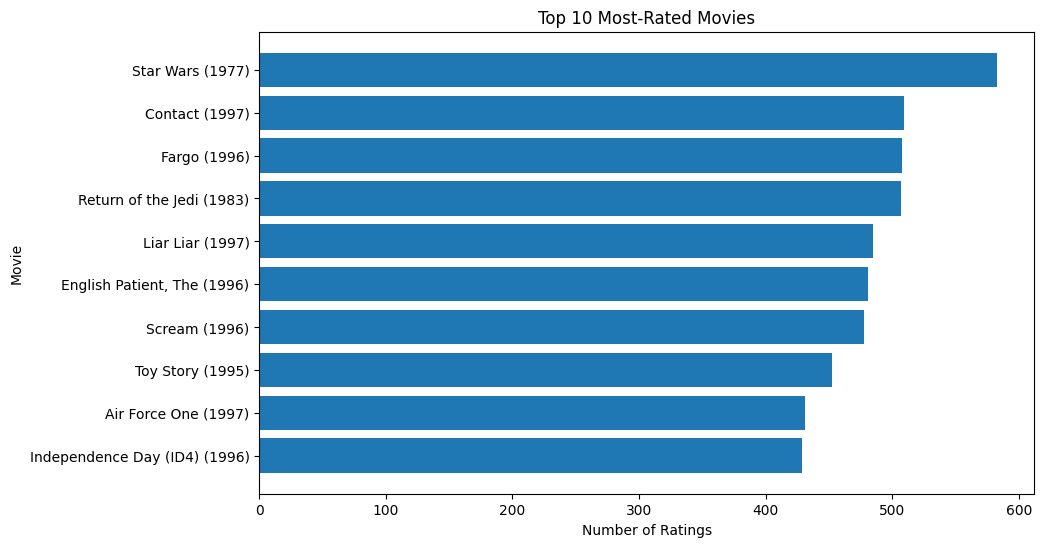

In [24]:
top_10 = most_rated_movies.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["title"],
    top_10["rating_count"]
)

plt.title("Top 10 Most-Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")

plt.gca().invert_yaxis()

plt.show()

In [25]:
movie_avg_ratings = (
    ratings.groupby("movieId")["rating"]
    .agg(["mean", "count"])
    .reset_index()
)

movie_avg_ratings.columns = [
    "movieId",
    "average_rating",
    "rating_count"
]

movie_avg_ratings.head()

,movieId,average_rating,rating_count
0,1,3.878319,452
1,2,3.206107,131
2,3,3.033333,90
3,4,3.550239,209
4,5,3.302326,86


In [26]:
popular_movies = movie_avg_ratings[
    movie_avg_ratings["rating_count"] >= 50
]

popular_movies = popular_movies.sort_values(
    "average_rating",
    ascending=False
)

popular_movies.head(10)

,movieId,average_rating,rating_count
407,408,4.491071,112
317,318,4.466443,298
168,169,4.466102,118
482,483,4.456790,243
113,114,4.447761,67
63,64,4.445230,283
602,603,4.387560,209
11,12,4.385768,267
49,50,4.358491,583
177,178,4.344000,125


In [27]:
top_rated_movies = (
    popular_movies
    .merge(movies[["movieId", "title"]], on="movieId")
)

top_rated_movies.head(10)

,movieId,average_rating,rating_count,title
0,408,4.491071,112,"Close Shave, A (1995)"
1,318,4.466443,298,Schindler's List (1993)
2,169,4.466102,118,"Wrong Trousers, The (1993)"
3,483,4.456790,243,Casablanca (1942)
4,114,4.447761,67,Wallace & Gromit: The Best of Aardman Animatio...
5,64,4.445230,283,"Shawshank Redemption, The (1994)"
6,603,4.387560,209,Rear Window (1954)
7,12,4.385768,267,"Usual Suspects, The (1995)"
8,50,4.358491,583,Star Wars (1977)
9,178,4.344000,125,12 Angry Men (1957)


In [28]:
user_rating_counts = (
    ratings.groupby("userId")
    .size()
    .reset_index(name="rating_count")
    .sort_values("rating_count", ascending=False)
)

user_rating_counts.head(10)

,userId,rating_count
404,405,737
654,655,685
12,13,636
449,450,540
275,276,518
415,416,493
536,537,490
302,303,484
233,234,480
392,393,448


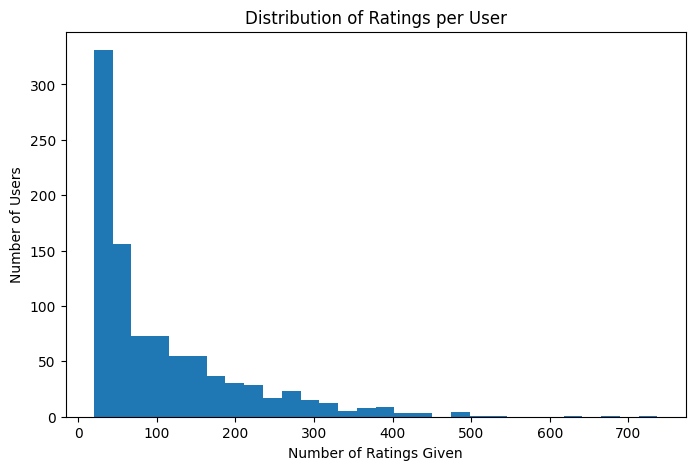

In [29]:
plt.figure(figsize=(8, 5))

plt.hist(
    user_rating_counts["rating_count"],
    bins=30
)

plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings Given")
plt.ylabel("Number of Users")

plt.show()

In [30]:
genre_columns = [
    "unknown",
    "Action",
    "Adventure",
    "Animation",
    "Children",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western"
]

In [31]:
movies_full = pd.read_csv(
    DATA_PATH / "u.item",
    sep="|",
    encoding="latin-1",
    header=None
)

movies_full.shape

(1682, 24)

In [32]:
movies_full.columns = [
    "movieId",
    "title",
    "release_date",
    "video_release_date",
    "IMDb_URL"
] + genre_columns

In [33]:
movies_full.head()

,movieId,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [34]:
genre_counts = movies_full[genre_columns].sum().sort_values(
    ascending=False
)

genre_counts

Drama          725
Comedy         505
Action         251
Thriller       251
Romance        247
Adventure      135
Children       122
Crime          109
Sci-Fi         101
Horror          92
War             71
Mystery         61
Musical         56
Documentary     50
Animation       42
Western         27
Film-Noir       24
Fantasy         22
unknown          2
dtype: int64

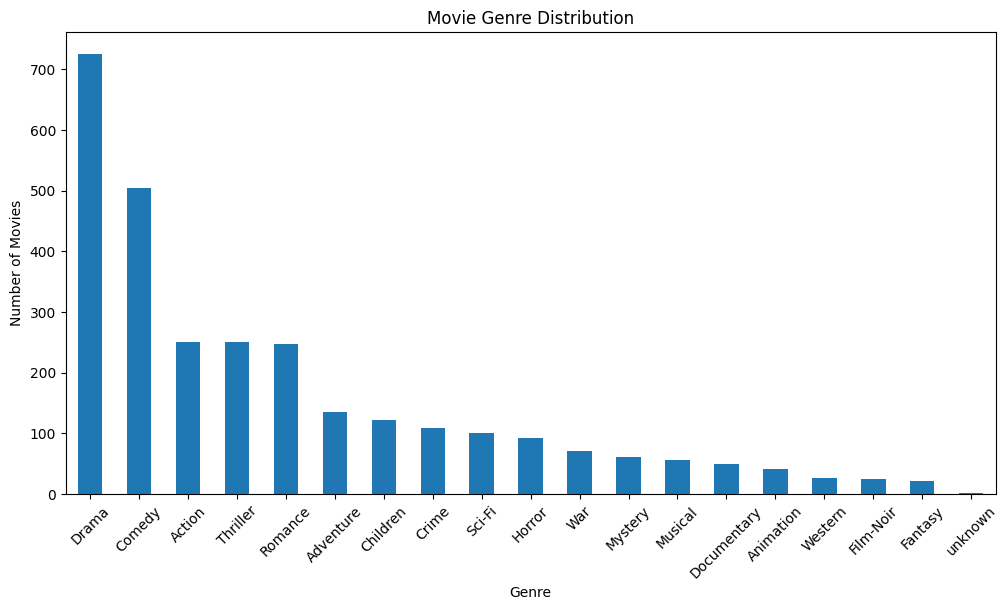

In [35]:
plt.figure(figsize=(12, 6))

genre_counts.plot(kind="bar")

plt.title("Movie Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)

plt.show()

In [36]:
print("Number of Users:", ratings["userId"].nunique())
print("Number of Movies:", ratings["movieId"].nunique())
print("Number of Ratings:", len(ratings))
print("Average rating:", ratings["rating"].mean())

Number of Users: 943
Number of Movies: 1682
Number of Ratings: 100000
Average rating: 3.52986


In [37]:
rating_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

rating_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
userId,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
print("Users:", rating_matrix.shape[0])
print("Movies:", rating_matrix.shape[1])

Users: 943
Movies: 1682


In [39]:
from sklearn.metrics.pairwise import cosine_similarity

In [40]:
movie_user_matrix = rating_matrix.fillna(0)

In [41]:
movie_user_matrix = movie_user_matrix.T

movie_user_matrix.head()

userId,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
movieId,,,,,,,,,,,,,,,,,,,,,
1,5.0,4.0,0.0,0.0,4.0,4.0,0.0,0.0,0.0,4.0,...,2.0,3.0,4.0,0.0,4.0,0.0,0.0,5.0,0.0,0.0
2,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,4.0,...,5.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
5,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [42]:
movie_similarity = cosine_similarity(movie_user_matrix)

In [43]:
movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=movie_user_matrix.index,
    columns=movie_user_matrix.index
)

movie_similarity_df.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
movieId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.402382,0.330245,0.454938,0.286714,0.116344,0.620979,0.481114,0.496288,0.273935,...,0.035387,0.0,0.000000,0.000000,0.035387,0.0,0.0,0.0,0.047183,0.047183
2,0.402382,1.000000,0.273069,0.502571,0.318836,0.083563,0.383403,0.337002,0.255252,0.171082,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.078299,0.078299
3,0.330245,0.273069,1.000000,0.324866,0.212957,0.106722,0.372921,0.200794,0.273669,0.158104,...,0.000000,0.0,0.000000,0.000000,0.032292,0.0,0.0,0.0,0.000000,0.096875
4,0.454938,0.502571,0.324866,1.000000,0.334239,0.090308,0.489283,0.490236,0.419044,0.252561,...,0.000000,0.0,0.094022,0.094022,0.037609,0.0,0.0,0.0,0.056413,0.075218
5,0.286714,0.318836,0.212957,0.334239,1.000000,0.037299,0.334769,0.259161,0.272448,0.055453,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.094211


In [44]:
def recommend_movies(movie_title, n=10):

    # Find movie ID
    movie_matches = movies[
        movies["title"].str.contains(
            movie_title,
            case=False,
            na=False
        )
    ]

    if movie_matches.empty:
        return "Movie not found."

    movie_id = movie_matches.iloc[0]["movieId"]

    # Check if movie exists in similarity matrix
    if movie_id not in movie_similarity_df.index:
        return "Movie does not have enough rating data."

    # Get similarity scores
    similarity_scores = movie_similarity_df[movie_id]

    # Sort by similarity
    similar_movie_ids = (
        similarity_scores
        .sort_values(ascending=False)
        .iloc[1:n+1]
        .index
    )

    # Get movie details
    recommendations = movies[
        movies["movieId"].isin(similar_movie_ids)
    ][["movieId", "title"]]

    # Add similarity score
    recommendations = recommendations.copy()

    recommendations["similarity"] = [
        similarity_scores[movie_id]
        for movie_id in recommendations["movieId"]
    ]

    recommendations = recommendations.sort_values(
        "similarity",
        ascending=False
    )

    return recommendations.reset_index(drop=True)

In [45]:
recommend_movies("Toy Story", 10)

,movieId,title,similarity
0,50,Star Wars (1977),0.734572
1,181,Return of the Jedi (1983),0.699925
2,121,Independence Day (ID4) (1996),0.689786
3,117,"Rock, The (1996)",0.664555
4,405,Mission: Impossible (1996),0.641322
5,151,Willy Wonka and the Chocolate Factory (1971),0.638158
6,222,Star Trek: First Contact (1996),0.636727
7,100,Fargo (1996),0.630601
8,237,Jerry Maguire (1996),0.624075
9,174,Raiders of the Lost Ark (1981),0.622382


In [46]:
recommend_movies("Star Wars", 10)
recommend_movies("Titanic", 10)

,movieId,title,similarity
0,272,Good Will Hunting (1997),0.591200
1,258,Contact (1997),0.552981
2,315,Apt Pupil (1998),0.548415
3,751,Tomorrow Never Dies (1997),0.534515
4,300,Air Force One (1997),0.530389
5,288,Scream (1996),0.514386
6,302,L.A. Confidential (1997),0.502545
7,328,Conspiracy Theory (1997),0.499881
8,286,"English Patient, The (1996)",0.496824
9,294,Liar Liar (1997),0.483865


In [50]:
test_movies = [
    "Toy Story",
    "Star Wars",
    "Titanic",
    "The Matrix",
    "Jurassic Park"
]

for movie in test_movies:
    print("\n" + "=" * 60)
    print(f"Recommendations for: {movie}")
    print("=" * 60)
    print(recommend_movies(movie, 5))
    


Recommendations for: Toy Story
   movieId                          title  similarity
0       50               Star Wars (1977)    0.734572
1      181      Return of the Jedi (1983)    0.699925
2      121  Independence Day (ID4) (1996)    0.689786
3      117               Rock, The (1996)    0.664555
4      405     Mission: Impossible (1996)    0.641322

Recommendations for: Star Wars
   movieId                            title  similarity
0      181        Return of the Jedi (1983)    0.884476
1      174   Raiders of the Lost Ark (1981)    0.764885
2      172  Empire Strikes Back, The (1980)    0.749819
3        1                 Toy Story (1995)    0.734572
4      127            Godfather, The (1972)    0.697332

Recommendations for: Titanic
   movieId                       title  similarity
0      272    Good Will Hunting (1997)    0.591200
1      258              Contact (1997)    0.552981
2      315            Apt Pupil (1998)    0.548415
3      751  Tomorrow Never Dies (1997)    

In [51]:
recommend_movies("Toy Story", 10)

,movieId,title,similarity
0,50,Star Wars (1977),0.734572
1,181,Return of the Jedi (1983),0.699925
2,121,Independence Day (ID4) (1996),0.689786
3,117,"Rock, The (1996)",0.664555
4,405,Mission: Impossible (1996),0.641322
5,151,Willy Wonka and the Chocolate Factory (1971),0.638158
6,222,Star Trek: First Contact (1996),0.636727
7,100,Fargo (1996),0.630601
8,237,Jerry Maguire (1996),0.624075
9,174,Raiders of the Lost Ark (1981),0.622382


In [52]:
movie_rating_counts = (
    ratings.groupby("movieId")
    .size()
    .reset_index(name="rating_count")
)

movie_rating_counts.head()

,movieId,rating_count
0,1,452
1,2,131
2,3,90
3,4,209
4,5,86


In [53]:
def recommend_movies(movie_title, n=10, min_ratings=20):

    movie_matches = movies[
        movies["title"].str.contains(
            movie_title,
            case=False,
            na=False
        )
    ]

    if movie_matches.empty:
        return "Movie not found."

    movie_id = movie_matches.iloc[0]["movieId"]

    if movie_id not in movie_similarity_df.index:
        return "Movie does not have enough rating data."

    similarity_scores = movie_similarity_df[movie_id]

    similar_movie_ids = (
        similarity_scores
        .sort_values(ascending=False)
        .iloc[1:]
        .index
    )

    recommendations = movies[
        movies["movieId"].isin(similar_movie_ids)
    ][["movieId", "title"]].copy()

    recommendations = recommendations.merge(
        movie_rating_counts,
        on="movieId",
        how="left"
    )

    recommendations["similarity"] = recommendations["movieId"].map(
        similarity_scores
    )

    recommendations = recommendations[
        recommendations["rating_count"] >= min_ratings
    ]

    recommendations = recommendations.sort_values(
        "similarity",
        ascending=False
    )

    return recommendations.head(n).reset_index(drop=True)

In [54]:
recommend_movies("Toy Story", 10)

,movieId,title,rating_count,similarity
0,50,Star Wars (1977),583,0.734572
1,181,Return of the Jedi (1983),507,0.699925
2,121,Independence Day (ID4) (1996),429,0.689786
3,117,"Rock, The (1996)",378,0.664555
4,405,Mission: Impossible (1996),344,0.641322
5,151,Willy Wonka and the Chocolate Factory (1971),326,0.638158
6,222,Star Trek: First Contact (1996),365,0.636727
7,100,Fargo (1996),508,0.630601
8,237,Jerry Maguire (1996),384,0.624075
9,174,Raiders of the Lost Ark (1981),420,0.622382


In [55]:
recommendations = recommend_movies("Toy Story", 10)

recommendations[
    ["title", "similarity", "rating_count"]
]

,title,similarity,rating_count
0,Star Wars (1977),0.734572,583
1,Return of the Jedi (1983),0.699925,507
2,Independence Day (ID4) (1996),0.689786,429
3,"Rock, The (1996)",0.664555,378
4,Mission: Impossible (1996),0.641322,344
5,Willy Wonka and the Chocolate Factory (1971),0.638158,326
6,Star Trek: First Contact (1996),0.636727,365
7,Fargo (1996),0.630601,508
8,Jerry Maguire (1996),0.624075,384
9,Raiders of the Lost Ark (1981),0.622382,420


In [58]:
toy_story_recommendations = recommend_movies(
    "Toy Story",
    n=10
)

toy_story_recommendations.to_csv(
    "D:/pr 1 internship/data/outputs/toy_story_recommendations.csv",
    index=False
)

In [60]:
from pathlib import Path

output_dir = Path("D:/pr 1 internship/data/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

print("Output folder ready!")

Output folder ready!


In [61]:
toy_story_recommendations.to_csv(
    output_dir / "toy_story_recommendations.csv",
    index=False
)

print("Recommendation file saved successfully!")

Recommendation file saved successfully!


In [62]:
toy_story_recommendations

,movieId,title,rating_count,similarity
0,50,Star Wars (1977),583,0.734572
1,181,Return of the Jedi (1983),507,0.699925
2,121,Independence Day (ID4) (1996),429,0.689786
3,117,"Rock, The (1996)",378,0.664555
4,405,Mission: Impossible (1996),344,0.641322
5,151,Willy Wonka and the Chocolate Factory (1971),326,0.638158
6,222,Star Trek: First Contact (1996),365,0.636727
7,100,Fargo (1996),508,0.630601
8,237,Jerry Maguire (1996),384,0.624075
9,174,Raiders of the Lost Ark (1981),420,0.622382


In [63]:
user_rating_counts.sort_values(
    "rating_count",
    ascending=False
).head(10)

,userId,rating_count
404,405,737
654,655,685
12,13,636
449,450,540
275,276,518
415,416,493
536,537,490
302,303,484
233,234,480
392,393,448


In [64]:
user_id = 1

In [65]:
user_movies = ratings[
    ratings["userId"] == user_id
].merge(
    movies[["movieId", "title"]],
    on="movieId"
)

user_movies.sort_values(
    "rating",
    ascending=False
).head(10)

,userId,movieId,rating,timestamp,title
254,1,204,5,875072688,Back to the Future (1985)
250,1,216,5,876892701,When Harry Met Sally... (1989)
244,1,198,5,878542717,Nikita (La Femme Nikita) (1990)
32,1,60,5,875072370,Three Colors: Blue (1993)
245,1,124,5,875071484,Lone Star (1996)
28,1,221,5,887431921,Breaking the Waves (1996)
242,1,165,5,874965518,Jean de Florette (1986)
17,1,64,5,875072404,"Shawshank Redemption, The (1994)"
22,1,114,5,875072173,Wallace & Gromit: The Best of Aardman Animatio...
19,1,228,5,878543541,Star Trek: The Wrath of Khan (1982)


In [66]:
def recommend_for_user(user_id, n=10):

    # Check whether user exists
    if user_id not in ratings["userId"].values:
        return "User not found."

    # Movies already rated by the user
    user_ratings = ratings[
        ratings["userId"] == user_id
    ]

    # Select movies the user rated highly
    liked_movies = user_ratings[
        user_ratings["rating"] >= 4
    ]

    if liked_movies.empty:
        return "User has no highly rated movies."

    recommendation_scores = {}

    # Find similar movies for each liked movie
    for movie_id in liked_movies["movieId"]:

        if movie_id not in movie_similarity_df.index:
            continue

        similarity_scores = movie_similarity_df[movie_id]

        for similar_movie_id, score in similarity_scores.items():

            # Don't recommend movies already watched
            if similar_movie_id in user_ratings["movieId"].values:
                continue

            if similar_movie_id not in recommendation_scores:
                recommendation_scores[similar_movie_id] = 0

            recommendation_scores[similar_movie_id] += score

    # Sort recommendations
    recommended_ids = sorted(
        recommendation_scores,
        key=recommendation_scores.get,
        reverse=True
    )[:n]

    recommendations = movies[
        movies["movieId"].isin(recommended_ids)
    ][["movieId", "title"]].copy()

    recommendations["score"] = recommendations["movieId"].map(
        recommendation_scores
    )

    recommendations = recommendations.sort_values(
        "score",
        ascending=False
    )

    return recommendations.reset_index(drop=True)

In [67]:
recommend_for_user(1, 10)

,movieId,title,score
0,423,E.T. the Extra-Terrestrial (1982),67.300408
1,655,Stand by Me (1986),62.885031
2,318,Schindler's List (1993),61.903411
3,568,Speed (1994),61.653032
4,357,One Flew Over the Cuckoo's Nest (1975),61.306741
5,403,Batman (1989),60.898409
6,385,True Lies (1994),60.612699
7,483,Casablanca (1942),59.755743
8,367,Clueless (1995),59.409127
9,433,Heathers (1989),59.299227


In [68]:
user_recommendations = recommend_for_user(1, 10)

user_recommendations.to_csv(
    output_dir / "user_1_recommendations.csv",
    index=False
)

print("User recommendations saved!")

User recommendations saved!


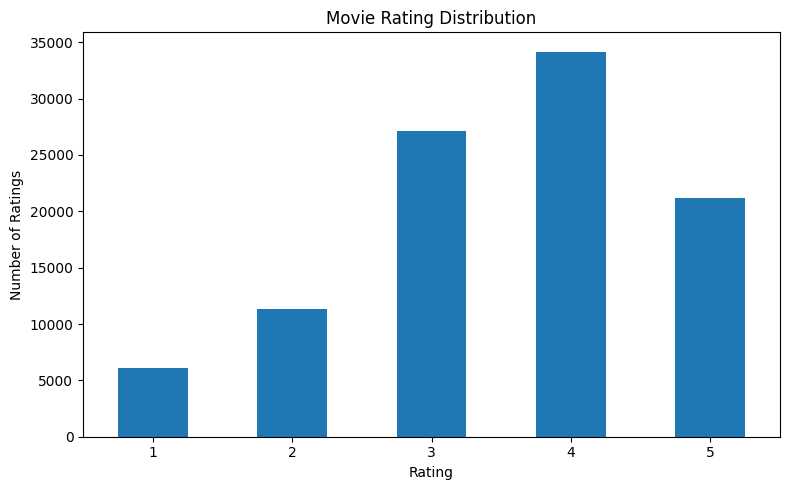

In [69]:
plt.figure(figsize=(8, 5))

ratings["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

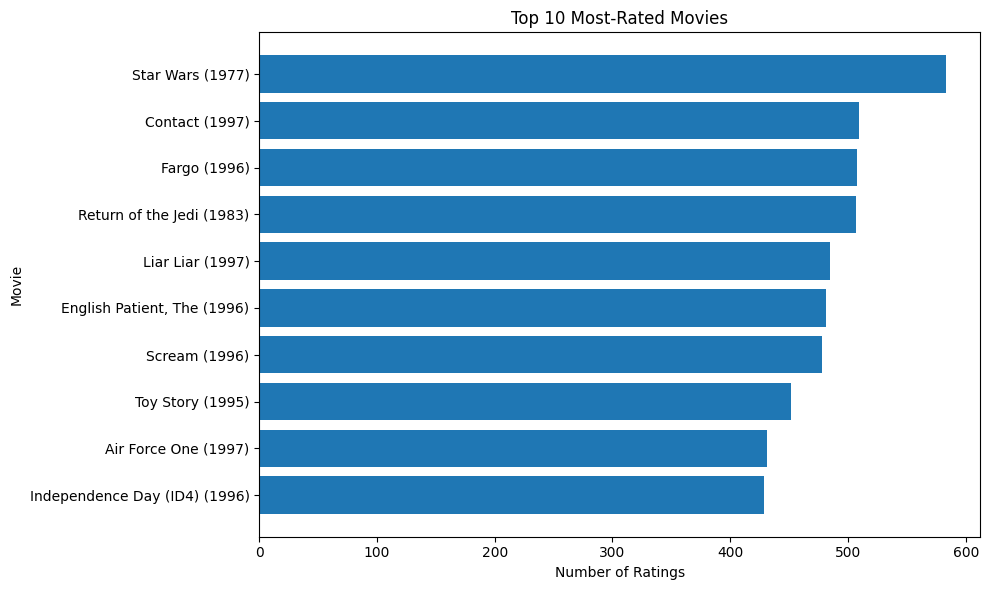

In [70]:
top_movies = (
    ratings.groupby("movieId")
    .size()
    .reset_index(name="rating_count")
    .merge(
        movies[["movieId", "title"]],
        on="movieId"
    )
    .sort_values("rating_count", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_movies["title"],
    top_movies["rating_count"]
)

plt.title("Top 10 Most-Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [71]:
top_rated = (
    ratings.groupby("movieId")["rating"]
    .agg(["mean", "count"])
    .reset_index()
)

top_rated.columns = [
    "movieId",
    "average_rating",
    "rating_count"
]

top_rated = top_rated[
    top_rated["rating_count"] >= 50
]

top_rated = (
    top_rated
    .merge(
        movies[["movieId", "title"]],
        on="movieId"
    )
    .sort_values(
        "average_rating",
        ascending=False
    )
    .head(10)
)

top_rated

,movieId,average_rating,rating_count,title
321,408,4.491071,112,"Close Shave, A (1995)"
273,318,4.466443,298,Schindler's List (1993)
140,169,4.466102,118,"Wrong Trousers, The (1993)"
376,483,4.456790,243,Casablanca (1942)
91,114,4.447761,67,Wallace & Gromit: The Best of Aardman Animatio...
51,64,4.445230,283,"Shawshank Redemption, The (1994)"
448,603,4.387560,209,Rear Window (1954)
10,12,4.385768,267,"Usual Suspects, The (1995)"
38,50,4.358491,583,Star Wars (1977)
149,178,4.344000,125,12 Angry Men (1957)


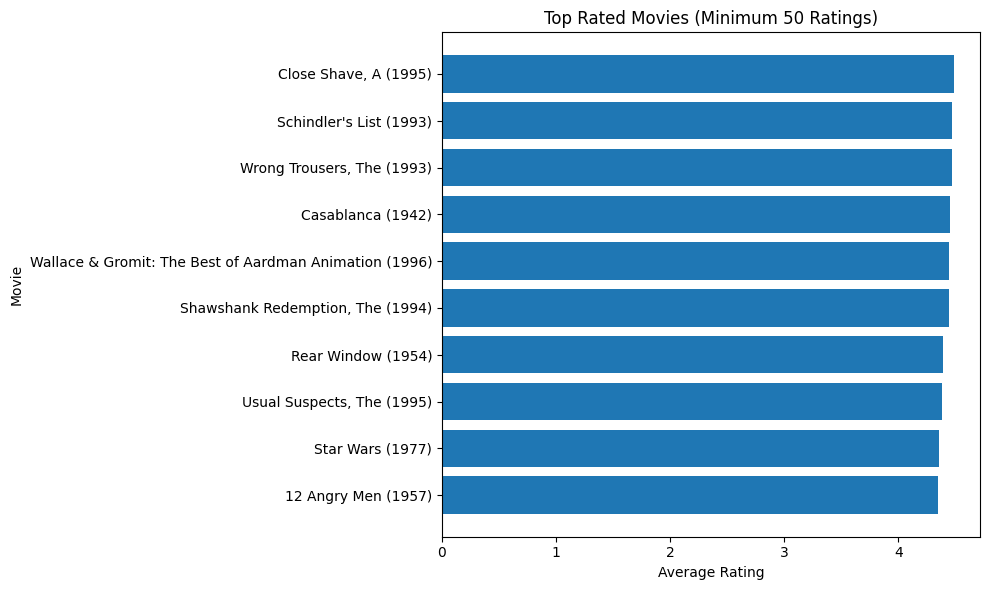

In [72]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_rated["title"],
    top_rated["average_rating"]
)

plt.title("Top Rated Movies (Minimum 50 Ratings)")
plt.xlabel("Average Rating")
plt.ylabel("Movie")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

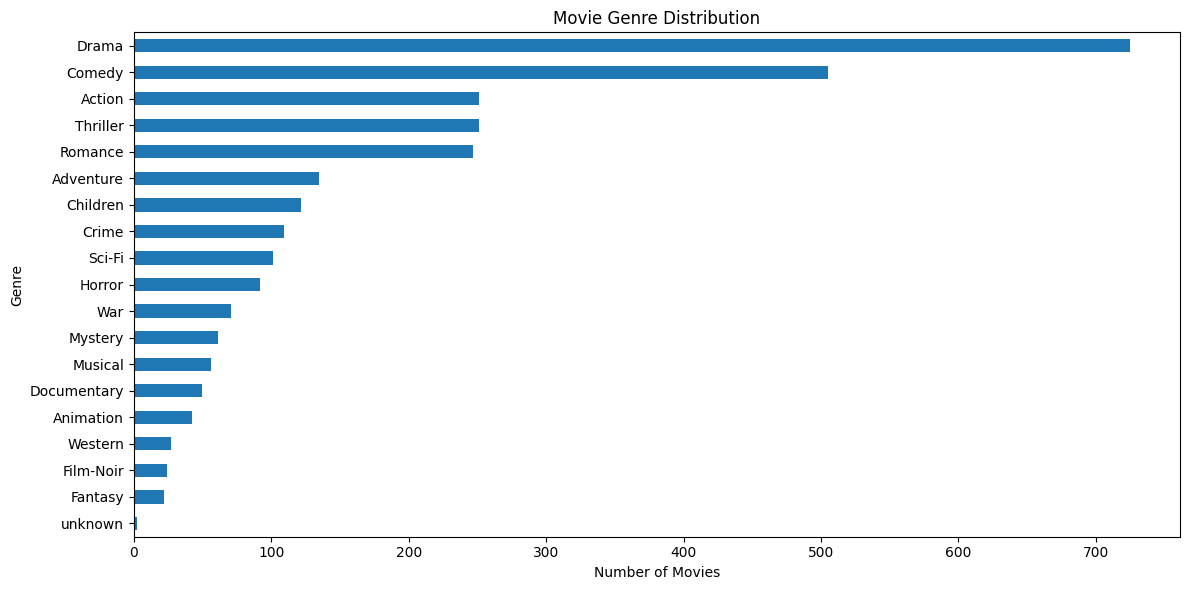

In [73]:
plt.figure(figsize=(12, 6))

genre_counts.sort_values().plot(kind="barh")

plt.title("Movie Genre Distribution")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

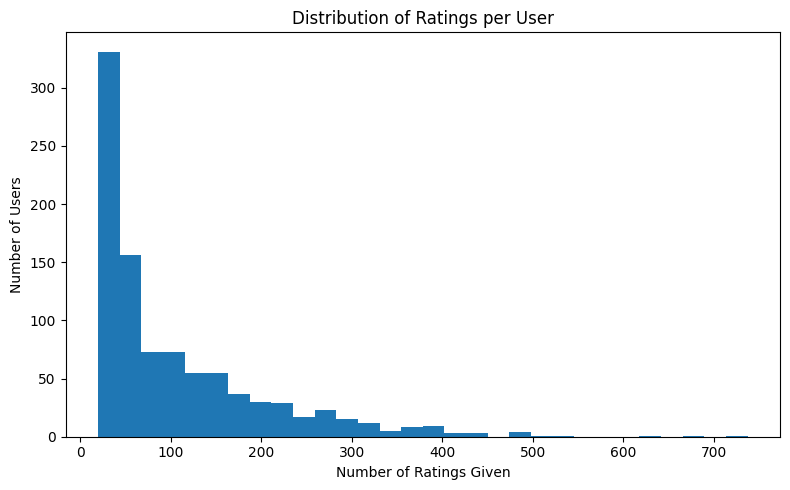

In [74]:
plt.figure(figsize=(8, 5))

plt.hist(
    user_rating_counts["rating_count"],
    bins=30
)

plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings Given")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

In [75]:
figures_dir = Path("D:/pr 1 internship/data/outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

print("Figures folder ready!")

Figures folder ready!


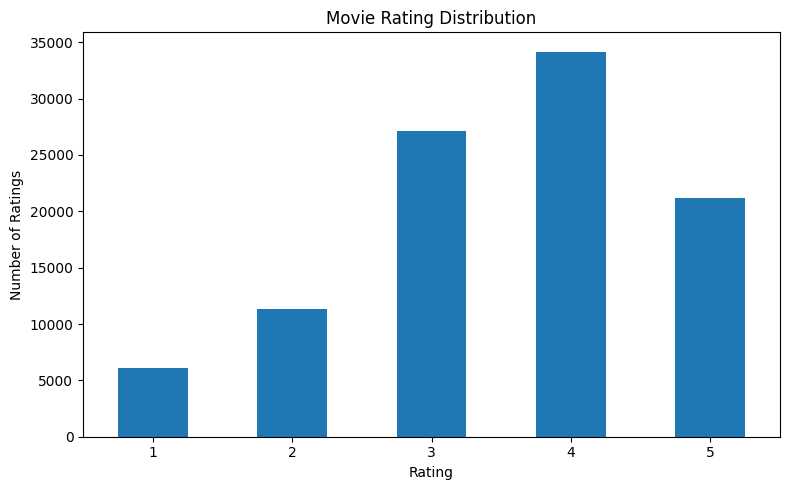

In [76]:
plt.figure(figsize=(8, 5))

ratings["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    figures_dir / "rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

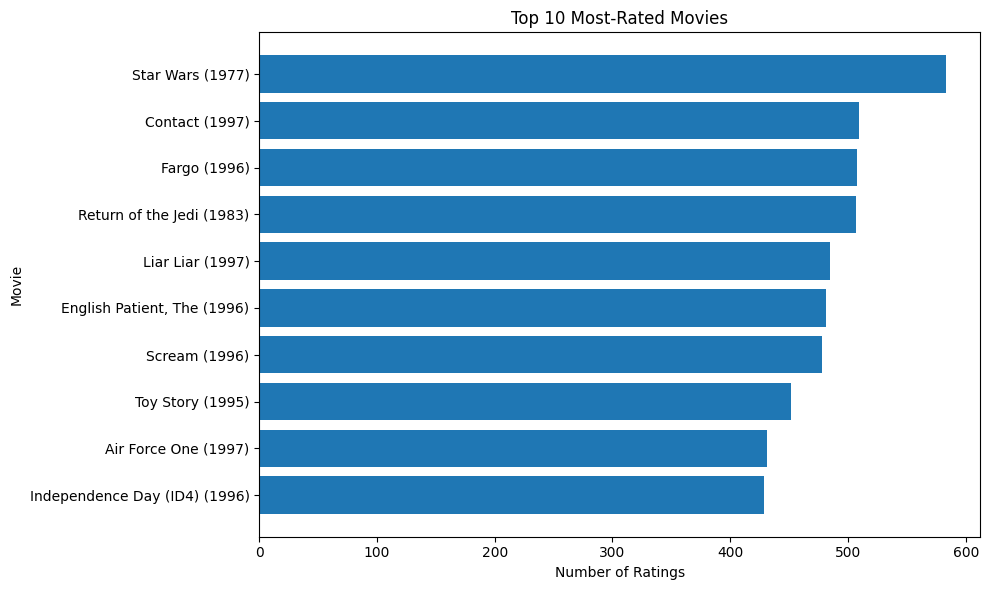

In [77]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_movies["title"],
    top_movies["rating_count"]
)

plt.title("Top 10 Most-Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    figures_dir / "most_rated_movies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

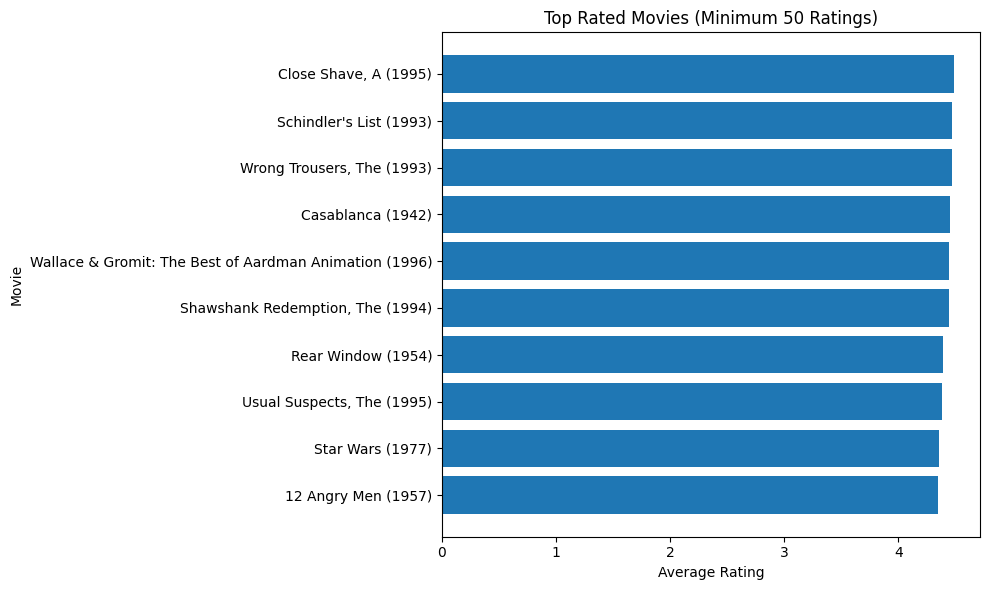

In [78]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_rated["title"],
    top_rated["average_rating"]
)

plt.title("Top Rated Movies (Minimum 50 Ratings)")
plt.xlabel("Average Rating")
plt.ylabel("Movie")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    figures_dir / "top_rated_movies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

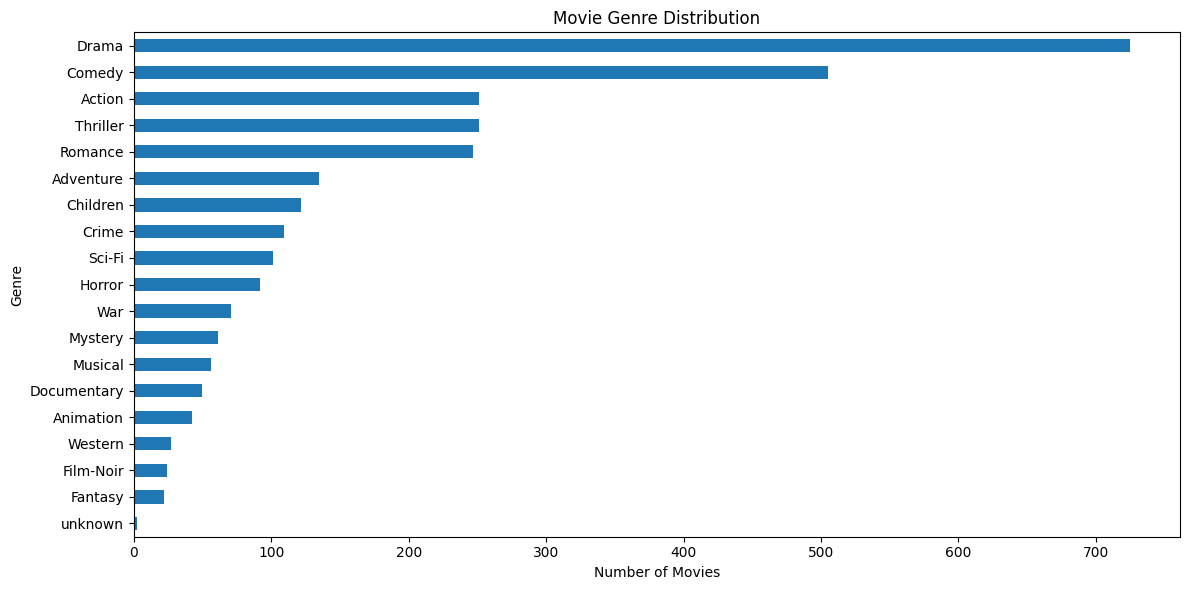

In [79]:
plt.figure(figsize=(12, 6))

genre_counts.sort_values().plot(kind="barh")

plt.title("Movie Genre Distribution")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.tight_layout()

plt.savefig(
    figures_dir / "genre_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

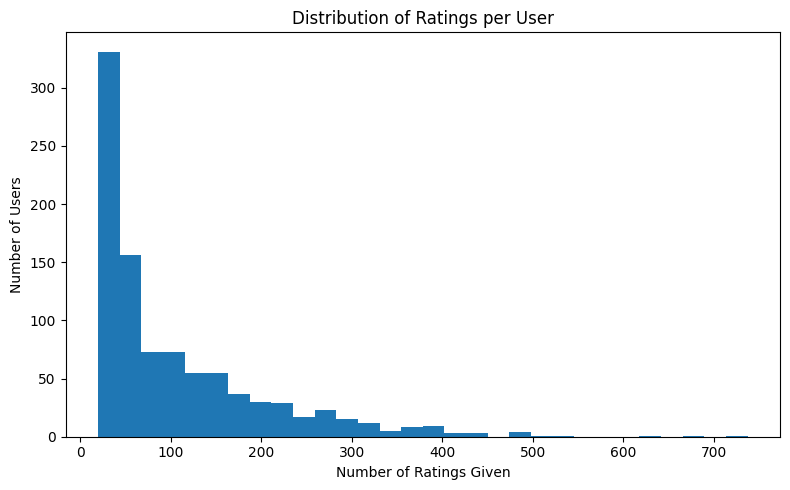

In [80]:
plt.figure(figsize=(8, 5))

plt.hist(
    user_rating_counts["rating_count"],
    bins=30
)

plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings Given")
plt.ylabel("Number of Users")

plt.tight_layout()

plt.savefig(
    figures_dir / "ratings_per_user.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [81]:
import joblib
from pathlib import Path

models_dir = Path("D:/pr 1 internship/models")
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(
    movie_similarity_df,
    models_dir / "movie_similarity.pkl"
)

print("Similarity model saved successfully!")

Similarity model saved successfully!


In [82]:
movies.to_pickle(
    models_dir / "movies.pkl"
)

ratings.to_pickle(
    models_dir / "ratings.pkl"
)

print("Movie and rating data saved!")

Movie and rating data saved!
